In [1]:
import numpy as np, pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

In [ ]:
def load_ace_data(file):
    cols = ["SCclock", "Epoch_start", "Epoch_end",
            "Br", "Bt", "Bn", "Bx", "By", "Bz",
            "Bmag", "dBrms", "wt"]
    
    df = pd.read_csv(
        file,
        sep=r"\s+",          
        engine="python",     
        skiprows=23,
        names=cols
    )
    
    df = df.apply(pd.to_numeric, errors='coerce')
    df["datetime"] = pd.to_datetime("1996-01-01") + pd.to_timedelta(df["Epoch_start"], unit="s")
    
    return df

In [7]:
files = [
    "ACE_MAG16_2017-256_V3-3",
    "ACE_MAG16_2017-257_V3-3",
    "ACE_MAG16_2017-258_V3-3",
    "ACE_MAG16_2017-259_V3-3",
    "ACE_MAG16_2017-260_V3-3",
    "ACE_MAG16_2017-261_V3-3",
    "ACE_MAG16_2017-262_V3-3",
    "ACE_MAG16_2017-264_V3-3",
    "ACE_MAG16_2017-266_V3-3",
    "ACE_MAG16_2017-268_V3-3",
    "ACE_MAG16_2017-270_V3-3"
]

dfs = [load_ace_data(f) for f in files]

In [ ]:
combined_df = pd.concat(dfs, ignore_index=True)
combined_df = combined_df.sort_values("datetime")
combined_df = combined_df[combined_df["Bmag"] != -999.9]
combined_df = combined_df[combined_df["dBrms"] != -999.9]


In [ ]:
combined_df["Bmag_smooth"] = combined_df["Bmag"].rolling(window=100, center=True).mean()
combined_df["B_fluct"] = combined_df["Bmag"] - combined_df["Bmag_smooth"]

# Total vector magnitude (more physical)
combined_df["B_total"] = np.sqrt(
    combined_df["Bx"]**2 +
    combined_df["By"]**2 +
    combined_df["Bz"]**2
)

# Vector fluctuation
combined_df["B_total_fluct"] = combined_df["B_total"] - combined_df["B_total"].rolling(100, center=True).mean()


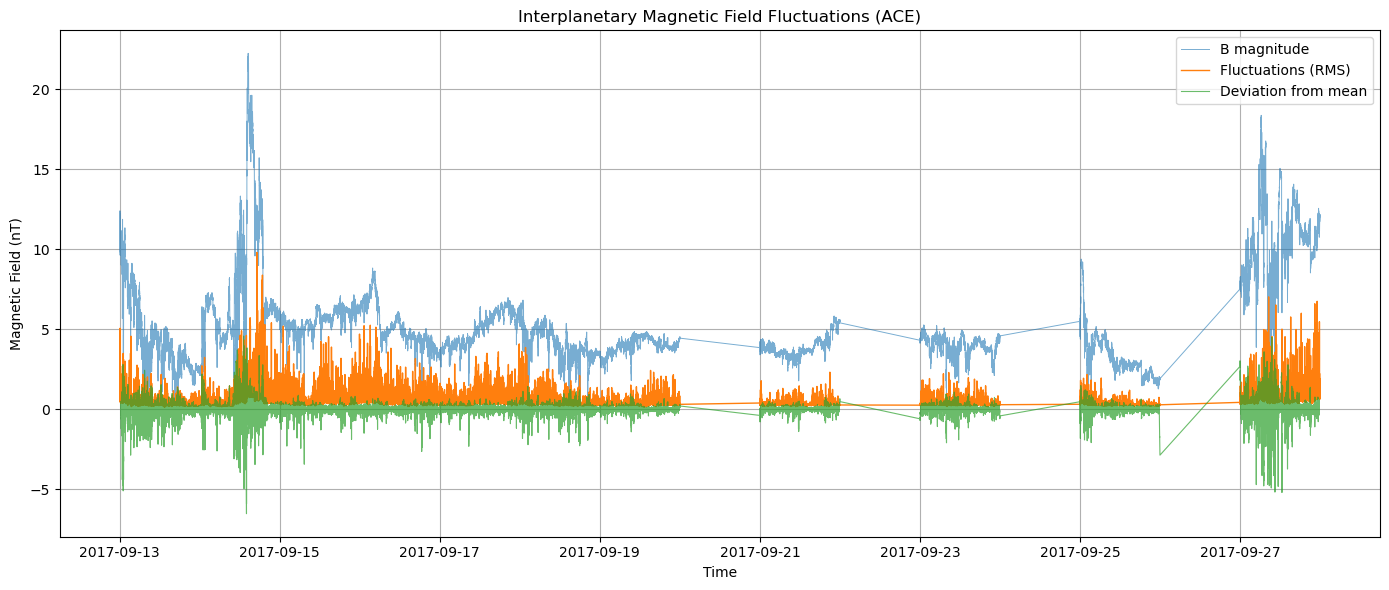

In [ ]:
plt.figure(figsize=(14,6))

# Main magnetic field
plt.plot(combined_df["datetime"], combined_df["Bmag"],
         linewidth=0.7, alpha=0.6, label="B magnitude")

# RMS fluctuations
plt.plot(combined_df["datetime"], combined_df["dBrms"],
         linewidth=1, label="Fluctuations (RMS)")

# Optional: fluctuation signal
plt.plot(combined_df["datetime"], combined_df["B_fluct"],
         linewidth=0.8, alpha=0.7, label="Deviation from mean")

plt.xlabel("Time")
plt.ylabel("Magnetic Field (nT)")
plt.title("Interplanetary Magnetic Field Fluctuations (ACE)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()